# Module 1 — Worksheet 1: From Business Question to EDA

**Course:** ISA 591 — Introduction to Data Mining in Business  
**Module 1:** Data Mining Overview  
**Focus:** Project framing, data understanding, exploratory data analysis, and data quality

This interactive worksheet follows one **end-to-end data mining project** using the Ames Housing dataset. Complete the `TODO` items and short responses as you work through the project.

## Learning goals

1. Describe the major stages of an end-to-end data mining project.
2. Translate a business problem into a supervised learning task.
3. Identify response and predictor variables.
4. Inspect numeric and categorical variables.
5. Use plots and summary statistics for exploratory data analysis.
6. Identify missing values, skewness, and basic data-quality issues.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## display at most 100 columns
pd.set_option("display.max_columns", 100)

---

# 1. The End-to-End Data Mining Roadmap

In this module, we will treat data mining as a **project**, not just a modeling step.

A practical workflow is:

1. **Define the business purpose**
2. **Obtain the data**
3. **Explore and understand the data**
4. **Prepare the data**
5. **Reduce/select features when useful**
6. **Split into training and test data**
7. **Fit candidate models**
8. **Evaluate and compare models**
9. **Interpret and communicate results**

Today we focus primarily on Steps **1–4**.

## Practice 1A — Identify the project stage

For each task, write the appropriate stage number from the roadmap above.

1. Compare RMSE for three candidate models: **8**
2. Discover that several variables contain missing values: **3**
3. Decide that the company wants to predict home sale price: **1**
4. Reserve part of the data for final evaluation: **6**
5. Present the best model and its business implications: **9**

---

# 2. Define the Business Purpose

Suppose a real-estate analytics company wants to estimate the selling price of a house using information known about the property.

The response variable in the Ames Housing data is:

`SalePrice`

In [ ]:
## SalePrice is numeric (target). 
# Regression Task 
# (Linear Regression (), 
# DT (decision trees) Regressors, 
# RF (random forests - ensemble) Regressors, 
# XGBoost (extreme gradient descent Reg - ensemble),  
# NN (neural network - feedforward architecture) Reg

## Practice 2A — Frame the problem

Answer:

1. What is the **business question**?
2. What is the **target / response variable**?
3. Is the target numeric or categorical?
4. Is this a **regression** or **classification** problem?
5. Is this **supervised** or **unsupervised** learning?

**Your response here:**  
1.  Predict sales price of homes
2.  SalePrice (log of sales price)
3.  Numeric
4.  Regression
5.  Supervised

---

# 3. Obtain and Inspect the Data

In [7]:
df = pd.read_csv("https://raw.githubusercontent.com/martinwg/ISA591/refs/heads/main/data/housing_ames.csv")

df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732.0,Unf,0.0,64.0,796.0,GasA,Ex,Y,SBrkr,796,566,0,1362,1.0,0.0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2.0,480.0,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369.0,Unf,0.0,317.0,1686.0,GasA,Ex,Y,SBrkr,1694,0,0,1694,1.0,0.0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2.0,636.0,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,80.0,10382,Pave,NaN,IR1,Lvl,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859.0,BLQ,32.0,216.0,1107.0,GasA,Ex,Y,SBrkr,1107,983,0,2090,1.0,0.0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2.0,484.0,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0.0,Unf,0.0,952.0,952.0,GasA,Gd,Y,FuseF,1022,752,0,1774,0.0,0.0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2.0,468.0,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,Met

In [8]:
## .info()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

## Practice 3A — First inspection

Complete the code to find:

- number of observations
- number of variables
- the target's data type

In [9]:
df.shape

(1460, 80)

In [ ]:
# TODO
n_observations = df.shape[0]
n_variables = df.shape[1]
target_dtype = df.SalePrice.dtype

print("Observations:", n_observations)
print("Variables:", n_variables)
print("SalePrice dtype:", target_dtype)

Observations: 1460
Variables: 80
SalePrice dtype: int64


## Practice 3B — Numeric vs. categorical variables

Separate the column names into:

- numeric columns
- categorical columns

In [12]:
df.select_dtypes(include = ["object"]).columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
       'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType',
       'SaleCondition'],
      dtype='object')

In [15]:
# TODO
numeric_cols = df.select_dtypes(include = ["int64", "float64", "int8"]).columns 
## numeric_cols = df.select_dtypes(include = np.number).columns
categorical_cols = df.select_dtypes(include = ["object", "category"]).columns

print("Number of numeric variables:", None if numeric_cols is None else len(numeric_cols))
print("Number of categorical variables:", None if categorical_cols is None else len(categorical_cols))

Number of numeric variables: 38
Number of categorical variables: 42


### Why does this distinction matter?

Why might numeric and categorical variables need different preparation before modeling?

**Your response here:**  
- Numeric variables (might need to transform with log to reduce skewness)
- Categorical variables (need to dummy encode or use other encodings)

---

# 4. Start EDA With the Target

Before looking at all predictors, first understand the variable we want to predict.

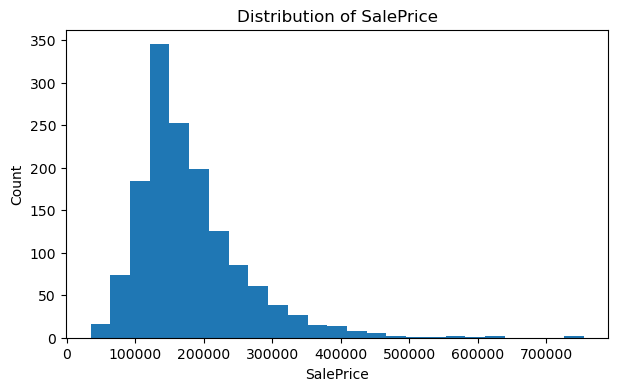

In [16]:
plt.figure(figsize=(7, 4))
plt.hist(df["SalePrice"], bins=25)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.show()

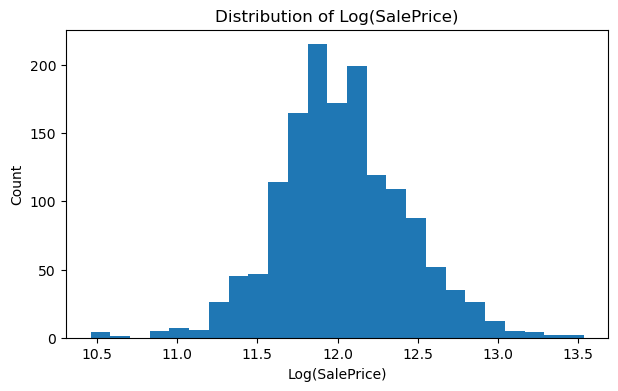

In [18]:
logsaleprice = np.log(df["SalePrice"])

plt.figure(figsize=(7, 4))
plt.hist(logsaleprice, bins=25)
plt.title("Distribution of Log(SalePrice)")
plt.xlabel("Log(SalePrice)")
plt.ylabel("Count")
plt.show()

## retrieve original SalePrice values from log-transformed values
original_saleprice = np.exp(logsaleprice)

## Practice 4A — Interpret `SalePrice`

Describe what you see.

1. Is the distribution approximately symmetric or skewed?
2. Are there unusually expensive homes?
3. Why might understanding the target distribution matter before modeling?

**Your response here:**  
1.  If fairly symmetric (no need for transformations)
2.  there are outliers
3.  Models can perform better with symmetric data with fewer outliers

---

# 5. Numeric EDA

## Practice 5A — Summary statistics

Use `.describe()` to summarize the numeric variables. Transpose the result so that variables appear as rows.

In [ ]:

# TODO
numeric_summary = df.describe()  ## all numeric columns are summarized by default.

numeric_summary

## difference of 75% and max to identify potential outliers

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.176370,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1868.739726,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,22.433457,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,453.697295,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1958.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,70.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1977.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Practice 5B — Explore selected numeric variables

Create histograms for:

- `GrLivArea`
- `OverallQual`
- `YearBuilt`

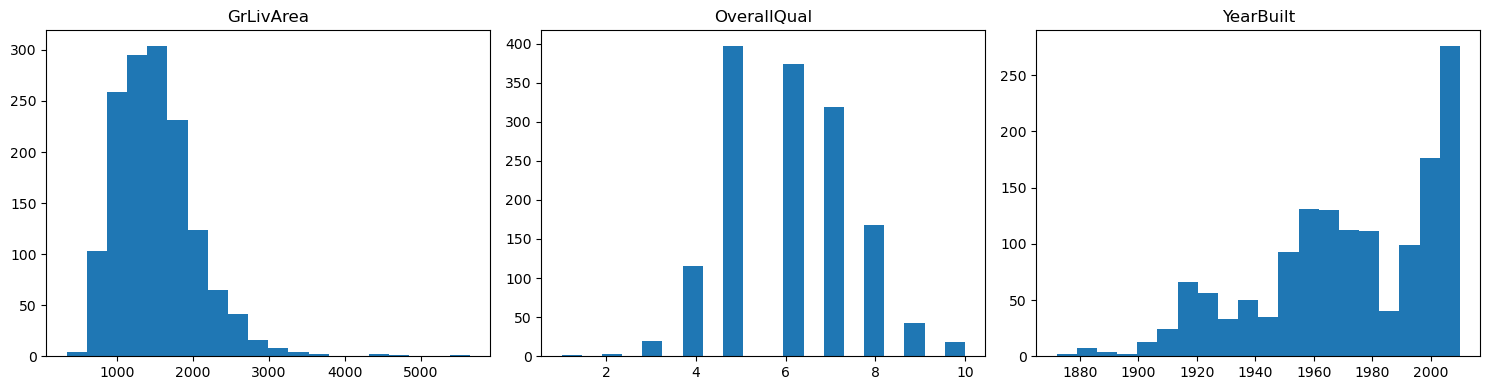

In [23]:
# TODO
variables = ["GrLivArea", "OverallQual", "YearBuilt"]
## select all columns
# variables = df.select_dtypes

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, variables):
     ax.hist(df[col].dropna(), bins=20)
     ax.set_title(col)
plt.tight_layout()
plt.show()

## Practice 5C — Skewness



In [ ]:
# identify potential issues with highly variables 
### get the most skewed numeric variables
### .skew() method returns the skewness of the data in each column

numeric_skewness = df[numeric_cols].skew().sort_values(ascending=False)
numeric_skewness

## we potentially can transform the most skewed variables to improve model performance

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.677616
OpenPorchSF       2.364342
LotFrontage       2.213556
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
Id                0.000000
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
G

### Interpretation

Why might a highly skewed variable sometimes be transformed before modeling?

**Your response here:**  
-

---

# 6. Categorical EDA

Useful questions for categorical predictors include:

- How many levels are there?
- Are some levels rare?
- Are some categories much more common than others?
- Will encoding create many new columns?

## Practice 6A — Inspect selected categorical variables

In [25]:
categorical_examples = ["Neighborhood", "HouseStyle", "SaleCondition"]

for col in categorical_examples:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(15))


--- Neighborhood ---
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
Name: count, dtype: int64

--- HouseStyle ---
HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

--- SaleCondition ---
SaleCondition
Normal     1198
Partial     125
Abnorml     101
Family       20
Alloca       12
AdjLand       4
Name: count, dtype: int64


In [27]:
## use .value_count() for the # levels of categorical variables
## number of unique levels for each categorical variable


# number of unique levels for each categorical variable
categorical_cardinality = (
    df[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
    .rename("n_levels")
    .to_frame()
)

categorical_cardinality

,n_levels
Neighborhood,25
Exterior2nd,16
Exterior1st,15
SaleType,9
Condition1,9
Condition2,8
RoofMatl,8
HouseStyle,8
Functional,7
RoofStyle,6


## Practice 6B — Bar chart

Create a bar chart for `HouseStyle`.

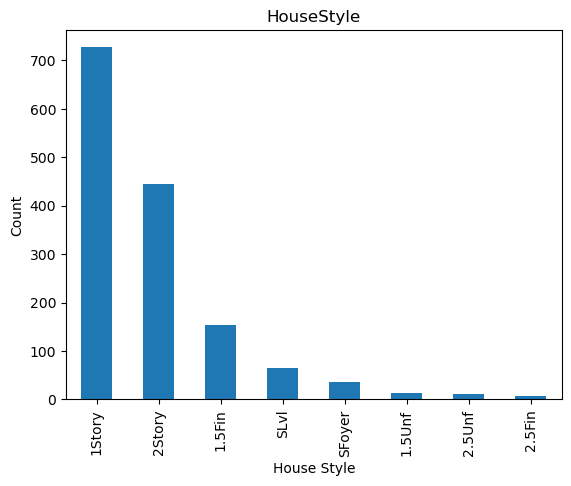

In [26]:

# TODO
df["HouseStyle"].value_counts().plot(kind="bar")
plt.title("HouseStyle")
plt.xlabel("House Style")
plt.ylabel("Count")
plt.show()

## Practice 6C — Cardinality

number of unique levels.

In [ ]:
## identify high cardinality (e.g., > 10 levels) 
## what to do: collapse levels (retain the most frequen and label "other" group, retain the most predictive levels ) 


---

# 7. Relationships With the Target

## Practice 7A — Scatter plot

Create a scatter plot of:

- x = `GrLivArea`
- y = `SalePrice`

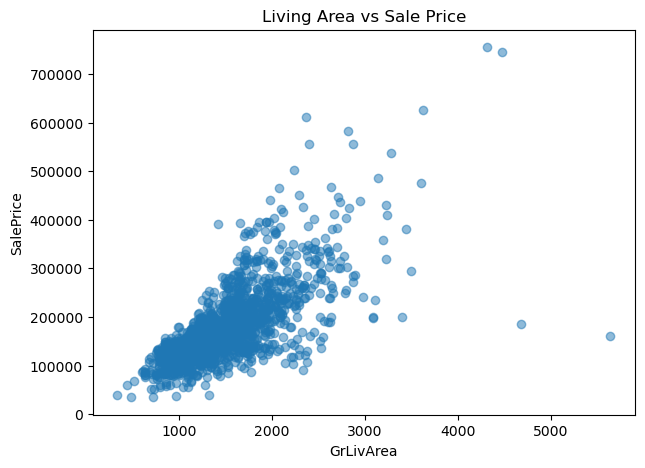

In [28]:

# TODO
plt.figure(figsize=(7, 5))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.5)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Living Area vs Sale Price")
plt.show()

### Interpretation

What relationship do you see? Are there any observations that look unusual?

**Your response here:**  
- Look for unsual relationships (variables might not look as if they had individually, but relationships can show unusual patterns)

## Practice 7B — Group comparison

Calculate the average `SalePrice` for each `OverallQual` level.

In [ ]:
df.groupby("OverallQual")["SalePrice"].mean()  ## relationship between cat and num 

OverallQual
1      50150.000000
2      51770.333333
3      87473.750000
4     108420.655172
5     133523.347607
6     161603.034759
7     207716.423197
8     274735.535714
9     367513.023256
10    438588.388889
Name: SalePrice, dtype: float64

---

# 8. Missing Values and Data Quality

Missing values do not always mean the same thing.

A missing value can represent:

- unknown information
- a data-entry problem
- a feature that does not apply

For example, missing `PoolQC` may mean the house has **no pool**, rather than that someone forgot to record pool quality.

## Practice 8A — Missing-value table

In [ ]:
## get number of missing values per variable
#### shows top 15 variables with the most missing 
df.isnull().sum().sort_values(ascending=False).to_frame("n_missing").head(15)

,n_missing
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
GarageType,81
GarageFinish,81
GarageQual,81
GarageCond,81


## Practice 8B — Think before imputing

Why might it be inappropriate to use the exact same missing-value rule for every variable?

**Your response here:**  
- Create levels, e.g., "No Pool" for PoolQC, "Unknown"

---

# 9. A Simple Introductory Cleaning Step

For this overview, we will use simple rules:

- `PoolQC`: missing means `"No Pool"`
- remaining categorical missing values: `"Unknown"`
- numeric missing values: median

These are introductory decisions. Later in the course, preprocessing learned from the data should be fitted using the **training set only**.

In [32]:

df_clean = df.copy()

df_clean["PoolQC"] = df_clean["PoolQC"].fillna("No Pool")

# TODO: fill remaining categorical missing values with "Unknown"
## would recommend you to understand every variable and the business context before filling missing values.
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].fillna("Unknown")

# TODO: fill numeric missing values with the median
for col in df_clean.select_dtypes(include=np.number).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values remaining:", df_clean.isna().sum().sum())

Missing values remaining: 0


In [34]:
df_clean.isnull().sum().sort_values(ascending=False).to_frame("n_missing").head(15)

,n_missing
Id,0
MSSubClass,0
GarageYrBlt,0
GarageType,0
FireplaceQu,0
Fireplaces,0
Functional,0
TotRmsAbvGrd,0
KitchenQual,0
KitchenAbvGr,0


In [38]:
## save the data for the next step of the project (EDA to Modeling)
df_clean.to_csv("housing_ames_cleaned.csv", index=False)

---

# 10. Lecture 1 Project Checkpoint

Complete the project summary:

| Question | Answer |
|---|---|
| Business objective |  |
| Target variable |  |
| Problem type |  |
| Learning type |  |
| One important numeric pattern |  |
| One important categorical pattern |  |
| One important data-quality issue |  |
| Next step in the project |  |

## Exit ticket

EDA is not just about creating plots. In one or two sentences, explain how EDA can influence what you do next in a data mining project.

**Your response here:**  
-